# Module 5, Class 5: Anomaly Detection and Association Rules

**Student:** Firdavs Boliev

This notebook uses Isolation Forest for anomaly detection and Apriori rules for simple basket analysis.


## 0. Setup

In [1]:
# Import anomaly detection, metrics, and association-rule tools.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")


Setup complete.


---
# Part 1: Anomaly Detection with Isolation Forest

Isolation Forest isolates anomalies by randomly selecting features and split values.  
Anomalies are "easy to isolate" — they require fewer splits.

## 1.1 Load Credit Card Fraud Dataset

In [2]:
# Load the credit card fraud dataset, using a deterministic fallback if the download fails.
# Credit Card Fraud dataset from Kaggle, hosted on a GitHub mirror.
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

try:
    df_full = pd.read_csv(url)
    print("Loaded credit card fraud data from the public URL.")
except Exception:
    print("Public fraud dataset unavailable. Generating a small fraud-like dataset.")
    rng = np.random.default_rng(42)
    n_normal = 9500
    n_fraud = 500
    normal = pd.DataFrame(rng.normal(0, 1, size=(n_normal, 28)), columns=[f"V{i}" for i in range(1, 29)])
    fraud = pd.DataFrame(rng.normal(2.5, 1.5, size=(n_fraud, 28)), columns=[f"V{i}" for i in range(1, 29)])
    normal["Time"] = rng.integers(0, 172800, n_normal)
    fraud["Time"] = rng.integers(0, 172800, n_fraud)
    normal["Amount"] = rng.gamma(2, 35, n_normal)
    fraud["Amount"] = rng.gamma(2, 120, n_fraud)
    normal["Class"] = 0
    fraud["Class"] = 1
    df_full = pd.concat([normal, fraud], ignore_index=True)

print(f"Full dataset: {df_full.shape}")
print("Class distribution:")
print(df_full['Class'].value_counts())
print(f"\nFraud rate: {df_full['Class'].mean()*100:.3f}%")


Loaded credit card fraud data from the public URL.
Full dataset: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%


In [3]:
# Sample the dataset so Isolation Forest runs quickly while keeping fraud rows.
# Sample 10K rows for speed (stratified to keep fraud ratio)
np.random.seed(42)
fraud = df_full[df_full['Class'] == 1]
normal = df_full[df_full['Class'] == 0].sample(n=10000 - len(fraud), random_state=42)
df = pd.concat([normal, fraud]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Sampled dataset: {df.shape}")
print(f"Class distribution:")
print(df['Class'].value_counts())

X = df.drop('Class', axis=1)
y_true = df['Class']


Sampled dataset: (10000, 31)
Class distribution:
Class
0    9508
1     492
Name: count, dtype: int64


## 1.2 Train Isolation Forest

In [4]:
# Train the first Isolation Forest model with a 1 percent contamination setting.
iso_forest = IsolationForest(
    contamination=0.01,  # Expected fraction of anomalies
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

iso_forest.fit(X)
print("Isolation Forest trained.")


Isolation Forest trained.


## 1.3 Predict Anomalies

In [5]:
# Convert Isolation Forest labels into 0 for normal and 1 for fraud.
# Isolation Forest: 1 = normal, -1 = anomaly
y_pred_raw = iso_forest.predict(X)

# Convert to match our labels: -1 -> 1 (fraud), 1 -> 0 (normal)
y_pred = (y_pred_raw == -1).astype(int)

print(f"Predicted anomalies: {y_pred.sum()}")
print(f"Actual frauds:      {y_true.sum()}")


Predicted anomalies: 100
Actual frauds:      492


In [6]:
# Evaluate the anomaly predictions with precision, recall, and F1.
# Evaluation
print("Isolation Forest — Fraud Detection Performance:")
print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_true, y_pred):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))


Isolation Forest — Fraud Detection Performance:
  Precision: 1.0000
  Recall:    0.2033
  F1 Score:  0.3378

              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      9508
       Fraud       1.00      0.20      0.34       492

    accuracy                           0.96     10000
   macro avg       0.98      0.60      0.66     10000
weighted avg       0.96      0.96      0.95     10000



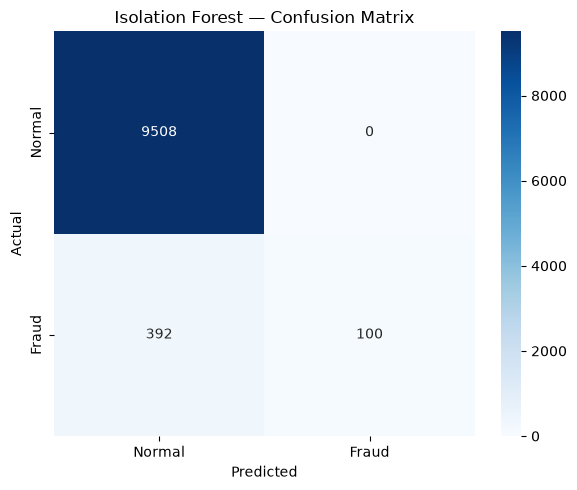

In [7]:
# Plot the confusion matrix for normal and fraud predictions.
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Isolation Forest — Confusion Matrix')
plt.tight_layout()
plt.show()


## 1.4 Anomaly Scores Distribution

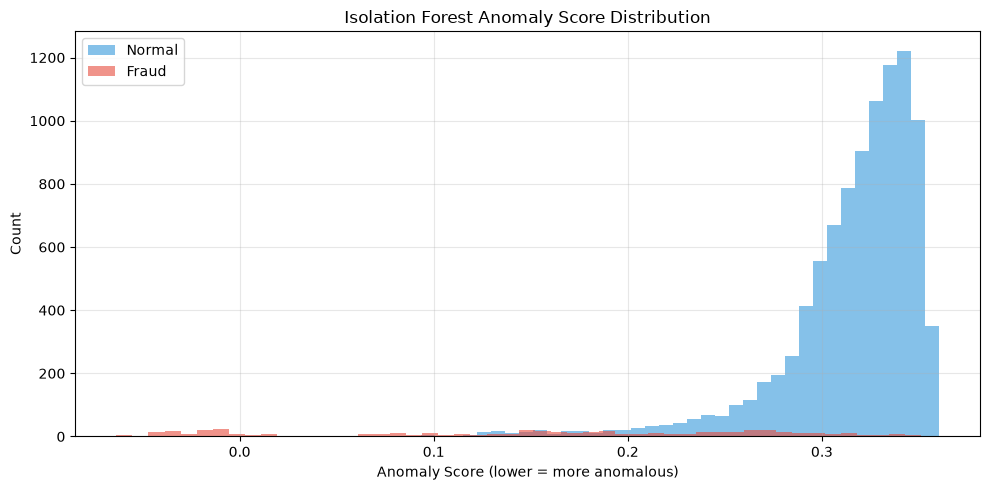

In [8]:
# Plot anomaly scores so normal and fraud distributions can be compared.
scores = iso_forest.decision_function(X)

plt.figure(figsize=(10, 5))
plt.hist(scores[y_true == 0], bins=50, alpha=0.6, label='Normal', color='#3498db')
plt.hist(scores[y_true == 1], bins=50, alpha=0.6, label='Fraud', color='#e74c3c')
plt.xlabel('Anomaly Score (lower = more anomalous)')
plt.ylabel('Count')
plt.title('Isolation Forest Anomaly Score Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 1.5 Try Different Contamination Values

The `contamination` parameter tells Isolation Forest what fraction of data is expected to be anomalous.  
Try values: `[0.005, 0.01, 0.02, 0.05]` and compare precision and recall.

In [9]:
# Try several contamination values and compare their metrics.
contamination_values = [0.005, 0.01, 0.02, 0.05]
results = []

for contamination in contamination_values:
    model = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100,
        n_jobs=-1,
    )
    model.fit(X)

    y_pred_raw = model.predict(X)
    y_pred_test = (y_pred_raw == -1).astype(int)

    results.append({
        "Contamination": contamination,
        "Precision": precision_score(y_true, y_pred_test),
        "Recall": recall_score(y_true, y_pred_test),
        "F1": f1_score(y_true, y_pred_test),
    })

contamination_df = pd.DataFrame(results).round(4)
contamination_df


,Contamination,Precision,Recall,F1
0,0.005,1.000,0.1016,0.1845
1,0.010,1.000,0.2033,0.3378
2,0.020,0.865,0.3516,0.5000
3,0.050,0.592,0.6016,0.5968


---
# Part 2: Association Rules with Apriori

Association rules discover patterns like: "Customers who buy bread and butter also buy milk."

## 2.1 Create Transaction Dataset

In [10]:
# Create a tiny grocery transaction dataset for association-rule mining.
# Small grocery store transactions
transactions = [
    ['bread', 'butter', 'milk'],
    ['bread', 'butter'],
    ['bread', 'milk', 'eggs'],
    ['butter', 'milk', 'eggs'],
    ['bread', 'butter', 'milk', 'eggs'],
    ['bread', 'butter', 'milk', 'cheese'],
    ['milk', 'cheese'],
    ['bread', 'eggs'],
    ['butter', 'milk', 'cheese'],
    ['bread', 'butter', 'milk', 'eggs', 'cheese'],
]

print(f"Number of transactions: {len(transactions)}")
for i, t in enumerate(transactions):
    print(f"  Transaction {i+1}: {t}")


Number of transactions: 10
  Transaction 1: ['bread', 'butter', 'milk']
  Transaction 2: ['bread', 'butter']
  Transaction 3: ['bread', 'milk', 'eggs']
  Transaction 4: ['butter', 'milk', 'eggs']
  Transaction 5: ['bread', 'butter', 'milk', 'eggs']
  Transaction 6: ['bread', 'butter', 'milk', 'cheese']
  Transaction 7: ['milk', 'cheese']
  Transaction 8: ['bread', 'eggs']
  Transaction 9: ['butter', 'milk', 'cheese']
  Transaction 10: ['bread', 'butter', 'milk', 'eggs', 'cheese']


## 2.2 Transaction Encoding

In [11]:
# Encode the transactions into a True/False item matrix.
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

print("Encoded transaction matrix:")
df_trans


Encoded transaction matrix:


,bread,butter,cheese,eggs,milk
0,True,True,False,False,True
1,True,True,False,False,False
2,True,False,False,True,True
3,False,True,False,True,True
4,True,True,False,True,True
5,True,True,True,False,True
6,False,False,True,False,True
7,True,False,False,True,False
8,False,True,True,False,True
9,True,True,True,True,True


## 2.3 Apriori — Frequent Itemsets

In [12]:
# Find frequent itemsets with the Apriori algorithm.
frequent_itemsets = apriori(df_trans, min_support=0.3, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"Frequent itemsets (min_support=0.3):")
print(frequent_itemsets.to_string(index=False))


Frequent itemsets (min_support=0.3):
 support                          itemsets
     0.8                 frozenset({milk})
     0.7                frozenset({bread})
     0.7               frozenset({butter})
     0.6         frozenset({milk, butter})
     0.5                 frozenset({eggs})
     0.5          frozenset({bread, milk})
     0.5        frozenset({bread, butter})
     0.4          frozenset({bread, eggs})
     0.4               frozenset({cheese})
     0.4           frozenset({milk, eggs})
     0.4         frozenset({cheese, milk})
     0.4  frozenset({bread, milk, butter})
     0.3       frozenset({cheese, butter})
     0.3         frozenset({eggs, butter})
     0.3    frozenset({bread, milk, eggs})
     0.3 frozenset({cheese, milk, butter})
     0.3   frozenset({milk, eggs, butter})


## 2.4 Association Rules

In [13]:
# Create association rules and sort them by lift.
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False)

# Display key columns
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(f"Association rules (min_confidence=0.5):")
print(f"Found {len(rules)} rules.\n")
print(rules[display_cols].to_string(index=False))


Association rules (min_confidence=0.5):
Found 32 rules.

                antecedents                consequents  support  confidence     lift
        frozenset({cheese})          frozenset({milk})      0.4    1.000000 1.250000
          frozenset({milk})        frozenset({cheese})      0.4    0.500000 1.250000
  frozenset({eggs, butter})          frozenset({milk})      0.3    1.000000 1.250000
  frozenset({milk, butter})        frozenset({cheese})      0.3    0.500000 1.250000
frozenset({cheese, butter})          frozenset({milk})      0.3    1.000000 1.250000
        frozenset({cheese})  frozenset({milk, butter})      0.3    0.750000 1.250000
   frozenset({bread, milk})          frozenset({eggs})      0.3    0.600000 1.200000
          frozenset({eggs})   frozenset({bread, milk})      0.3    0.600000 1.200000
   frozenset({bread, milk})        frozenset({butter})      0.4    0.800000 1.142857
        frozenset({butter})   frozenset({bread, milk})      0.4    0.571429 1.142857
        

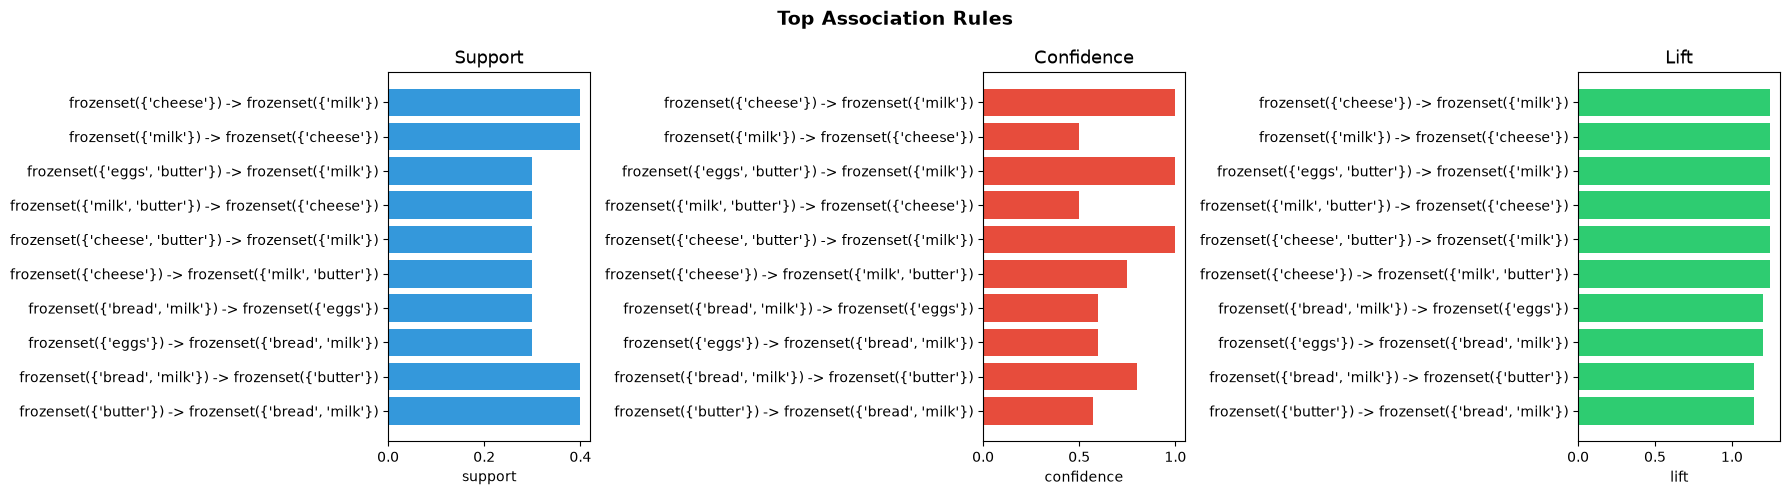

In [14]:
# Plot the top association rules by support, confidence, and lift.
# Visualize top rules by lift
top_rules = rules.head(10).copy()
top_rules['rule'] = top_rules['antecedents'].astype(str) + ' -> ' + top_rules['consequents'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(['support', 'confidence', 'lift']):
    axes[i].barh(top_rules['rule'], top_rules[metric], color=['#3498db', '#e74c3c', '#2ecc71'][i])
    axes[i].set_title(metric.capitalize(), fontsize=13)
    axes[i].invert_yaxis()
    axes[i].set_xlabel(metric)

plt.suptitle('Top Association Rules', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Key Metrics Explained

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Support** | P(A and B) | How frequently the items appear together |
| **Confidence** | P(B \| A) | If A is bought, how likely is B? |
| **Lift** | P(B \| A) / P(B) | Lift > 1 means A and B appear together more than by chance |

## 2.5 Interpret the Top 3 Rules

Look at the top 3 rules (sorted by lift) and for each one explain:
1. What the rule says in plain English
2. Whether the lift value suggests a meaningful association or just random co-occurrence
3. How a store manager could use this rule to increase sales

**Task: Your interpretation here**

*Rule 1:*

*Rule 2:*

*Rule 3:*


---
## Summary

| Concept | Details |
|---------|--------|
| Isolation Forest | Unsupervised anomaly detection — isolates outliers with random splits |
| contamination | Expected anomaly fraction — directly controls the decision threshold |
| Apriori | Finds frequent itemsets by pruning infrequent candidates level by level |
| Support | Fraction of transactions containing the itemset |
| Confidence | Conditional probability: P(consequent \| antecedent) |
| Lift | > 1 means positive association, = 1 means independent, < 1 means negative association |